In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

base = '/Users/parthshringarpure/Desktop/AI/Projects/luad_survival'

print(f"SHAP version: {shap.__version__}")
print("All imports successful ✅")

/opt/anaconda3/envs/luad_survival/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.49.1
All imports successful ✅


In [2]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from lifelines import CoxPHFitter

# Load all streams
expr     = pd.read_csv(f'{base}/data/processed/expression_matrix.csv', index_col=0)
dysreg   = pd.read_csv(f'{base}/data/processed/dysregulation_scores.csv', index_col=0)
immune   = pd.read_csv(f'{base}/data/processed/immune_features_cibersort.csv', index_col=0)
clinical = pd.read_csv(f'{base}/data/processed/clinical_survival.csv', index_col=0)

# Align patients
common   = expr.index.intersection(dysreg.index).intersection(
           immune.index).intersection(clinical.index)
expr     = expr.loc[common]
dysreg   = dysreg.loc[common]
immune   = immune.loc[common]
clinical = clinical.loc[common]

# Clinical features
age           = clinical[['age']].copy()
gender        = (clinical['gender'] == 'male').astype(float).to_frame()
stage_dummies = pd.get_dummies(clinical['stage_group'], prefix='stage')
stage_dummies = stage_dummies.drop(columns=['stage_Stage I'], errors='ignore')
clinical_features = pd.concat([age, gender, stage_dummies], axis=1).astype(float).fillna(0)

# Survival labels
y = np.array(
    [(bool(e), t) for e, t in zip(clinical['event'], clinical['survival_time'])],
    dtype=[('event', bool), ('time', float)]
)

# Cox gene selection on ALL data
print("Selecting top features by Cox p-value on full dataset...")
times  = y['time']
events = y['event']

cox_pvals_expr = {}
for gene in expr.columns:
    try:
        df_tmp = pd.DataFrame({'T': times, 'E': events, 'gene': expr[gene].values})
        cph = CoxPHFitter()
        cph.fit(df_tmp, duration_col='T', event_col='E', show_progress=False)
        cox_pvals_expr[gene] = cph.summary['p'].values[0]
    except:
        cox_pvals_expr[gene] = 1.0
top_expr = pd.Series(cox_pvals_expr).nsmallest(50).index
print(f"Expression: top 50 selected ✅")

cox_pvals_dysreg = {}
for gene in dysreg.columns:
    try:
        df_tmp = pd.DataFrame({'T': times, 'E': events, 'gene': dysreg[gene].values})
        cph = CoxPHFitter()
        cph.fit(df_tmp, duration_col='T', event_col='E', show_progress=False)
        cox_pvals_dysreg[gene] = cph.summary['p'].values[0]
    except:
        cox_pvals_dysreg[gene] = 1.0
top_dysreg = pd.Series(cox_pvals_dysreg).nsmallest(30).index
print(f"Dysregulation: top 30 selected ✅")

# Build feature matrix
X = pd.concat([
    expr[top_expr],
    dysreg[top_dysreg],
    immune,
    clinical_features
], axis=1)

# Add stream labels for each feature
feature_streams = (
    ['Expression'] * 50 +
    ['Dysregulation'] * 30 +
    ['Immune'] * 22 +
    ['Clinical'] * 5
)

print(f"\nFeature matrix: {X.shape}")

# Scale and train final model on ALL data
scaler  = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

model_final = GradientBoostingSurvivalAnalysis(
    n_estimators=200, learning_rate=0.05, max_depth=2,
    min_samples_split=20, min_samples_leaf=10,
    subsample=0.8, random_state=42)
model_final.fit(X_scaled, y)

print(f"Final XGBoost model trained on all {len(X)} patients ✅")

Selecting top features by Cox p-value on full dataset...
Expression: top 50 selected ✅
Dysregulation: top 30 selected ✅

Feature matrix: (478, 107)
Final XGBoost model trained on all 478 patients ✅


In [4]:
print("Computing SHAP values for all 478 patients...")

# Extract the underlying sklearn GradientBoostingRegressor
# sksurv wraps sklearn's GB — we access the internal estimator
import sklearn.ensemble

# Get the base estimator from sksurv model
base_model = model_final.estimators_[0][0]
print(f"Base estimator type: {type(base_model)}")

# Use Permutation explainer which works with any model
# It's slower but universal
explainer = shap.Explainer(
    model_final.predict,
    X_scaled,
    max_evals=2 * X_scaled.shape[1] + 1
)

print("Running SHAP permutation explainer...")
shap_values = explainer(X_scaled)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Any NaN: {np.isnan(shap_values.values).any()}")

np.save(f'{base}/data/processed/shap_values_xgb.npy', shap_values.values)
print(f"\nSaved: data/processed/shap_values_xgb.npy")

Computing SHAP values for all 478 patients...
Base estimator type: <class 'sklearn.tree._classes.DecisionTreeRegressor'>
Running SHAP permutation explainer...


PermutationExplainer explainer: 479it [00:12,  9.54it/s]                         


SHAP values shape: (478, 107)
Any NaN: False

Saved: data/processed/shap_values_xgb.npy


In [5]:
import matplotlib.pyplot as plt
import os
os.makedirs(f'{base}/outputs/figures', exist_ok=True)

# Colour each feature by its stream
stream_colors = {
    'Expression': '#2196F3',      # blue
    'Dysregulation': '#FF9800',   # orange  
    'Immune': '#4CAF50',          # green
    'Clinical': '#9C27B0'         # purple
}

# Get mean absolute SHAP per feature
mean_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'stream': feature_streams,
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False)

print("Top 20 most important features:")
print("-" * 55)
print(f"{'Rank':<6} {'Feature':<25} {'Stream':<15} {'SHAP':<10}")
print("-" * 55)
for i, row in feature_importance.head(20).iterrows():
    print(f"{list(feature_importance.index).index(i)+1:<6} {row['feature']:<25} {row['stream']:<15} {row['mean_shap']:.4f}")

# Stream-level importance
print(f"\nStream-level importance:")
stream_importance = feature_importance.groupby('stream')['mean_shap'].sum().sort_values(ascending=False)
for stream, importance in stream_importance.items():
    pct = importance / stream_importance.sum() * 100
    bar = '█' * int(pct / 2)
    print(f"  {stream:<15} {pct:.1f}%  {bar}")

# Save feature importance
feature_importance.to_csv(f'{base}/outputs/results/shap_feature_importance.csv', index=False)
print(f"\nSaved: outputs/results/shap_feature_importance.csv")

Top 20 most important features:
-------------------------------------------------------
Rank   Feature                   Stream          SHAP      
-------------------------------------------------------
1      stage_Stage III           Clinical        0.1418
2      CLEC18A                   Expression      0.0662
3      EPGN                      Dysregulation   0.0605
4      EPGN                      Expression      0.0522
5      SLC24A5                   Expression      0.0470
6      CLEC18A                   Dysregulation   0.0443
7      DKK1                      Dysregulation   0.0375
8      CMAH                      Expression      0.0374
9      DKK1                      Expression      0.0353
10     HABP2                     Expression      0.0334
11     PPP1R3G                   Dysregulation   0.0316
12     LINGO2                    Dysregulation   0.0303
13     LINGO2                    Expression      0.0278
14     SLC47A1                   Dysregulation   0.0251
15     IRX5 

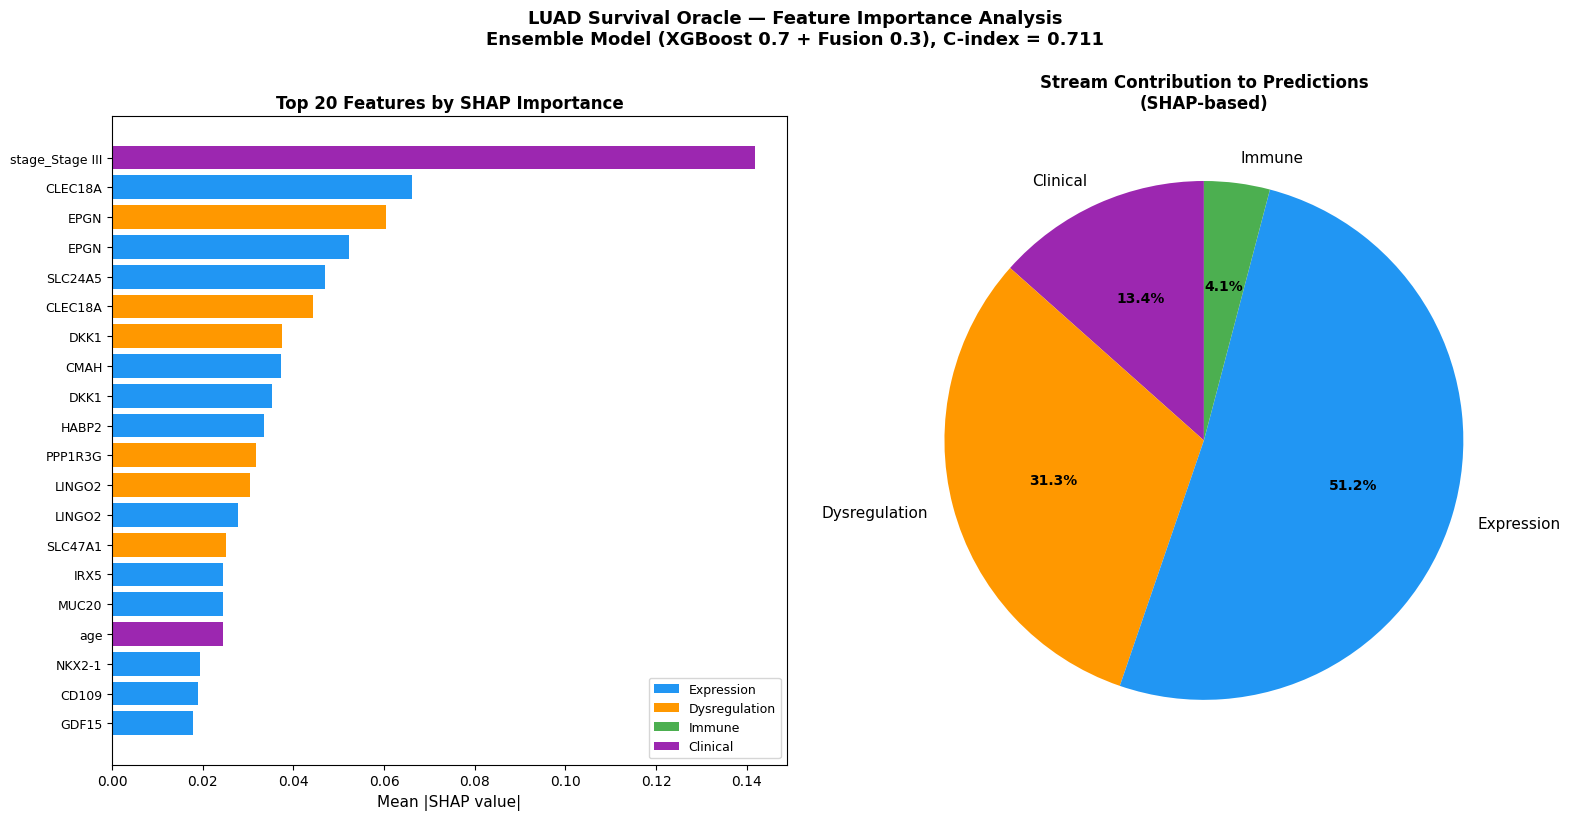

Saved: outputs/figures/shap_feature_importance.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Plot 1: Top 20 feature importance bar chart ──────────────────
top20 = feature_importance.head(20).copy()
top20 = top20.iloc[::-1]  # reverse for horizontal bar

colors = [stream_colors[s] for s in top20['stream']]

axes[0].barh(range(len(top20)), top20['mean_shap'], color=colors)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'], fontsize=9)
axes[0].set_xlabel('Mean |SHAP value|', fontsize=11)
axes[0].set_title('Top 20 Features by SHAP Importance', fontsize=12, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in stream_colors.items()]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# ── Plot 2: Stream contribution pie chart ────────────────────────
stream_pcts = feature_importance.groupby('stream')['mean_shap'].sum()
stream_pcts = stream_pcts / stream_pcts.sum() * 100

colors_pie = [stream_colors[s] for s in stream_pcts.index]
wedges, texts, autotexts = axes[1].pie(
    stream_pcts.values,
    labels=stream_pcts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

axes[1].set_title('Stream Contribution to Predictions\n(SHAP-based)', 
                   fontsize=12, fontweight='bold')

plt.suptitle('LUAD Survival Oracle — Feature Importance Analysis\n'
             'Ensemble Model (XGBoost 0.7 + Fusion 0.3), C-index = 0.711',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/shap_feature_importance.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/shap_feature_importance.png")

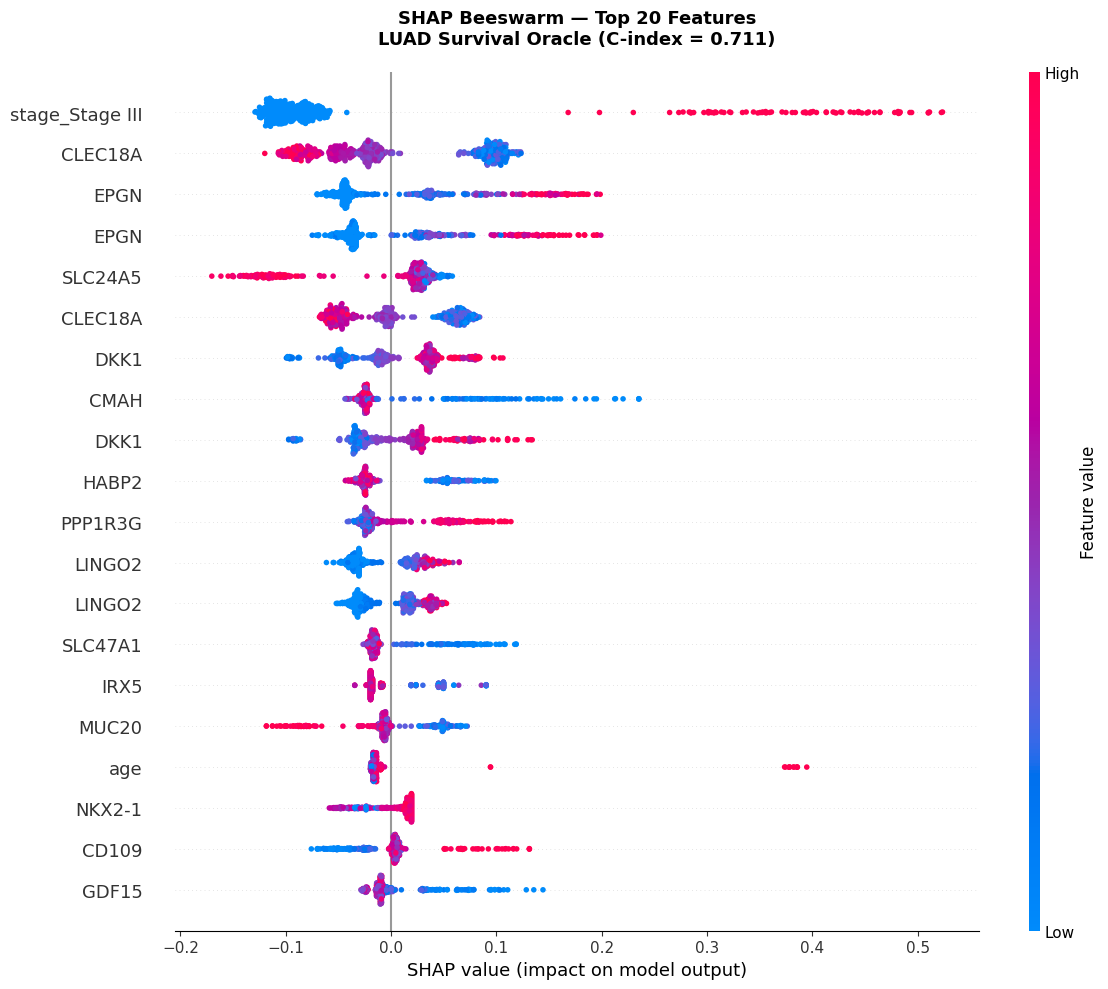

Saved: outputs/figures/shap_beeswarm.png


In [7]:
plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values.values,
    X_scaled,
    feature_names=list(X.columns),
    max_display=20,
    show=False,
    plot_size=(12, 10)
)

plt.title('SHAP Beeswarm — Top 20 Features\nLUAD Survival Oracle (C-index = 0.711)', 
          fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/shap_beeswarm.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/shap_beeswarm.png")